In [1]:
from astropy.io import ascii, fits
from astropy.table import Table
from run_prospector_new import *
from prospect.io import read_results as pread
import pandas as pd
import corner
import matplotlib.pyplot as plt
import numpy as np
import plotfancy as pf

In [2]:
TAB = Table(ascii.read('sedrun.csv'))
ROW = TAB[0]
FILE = 'out/224d52m16pt41356234s-18d10m42pt80767292sresults_1.h5'
model = build_model(ROW)
model_params = model.theta_labels()
# from run_prosp_nonparaSFH import build_model, build_sps
results, observations_dict, _ = pread.results_from(FILE)
sps = pread.get_sps(results)

building model


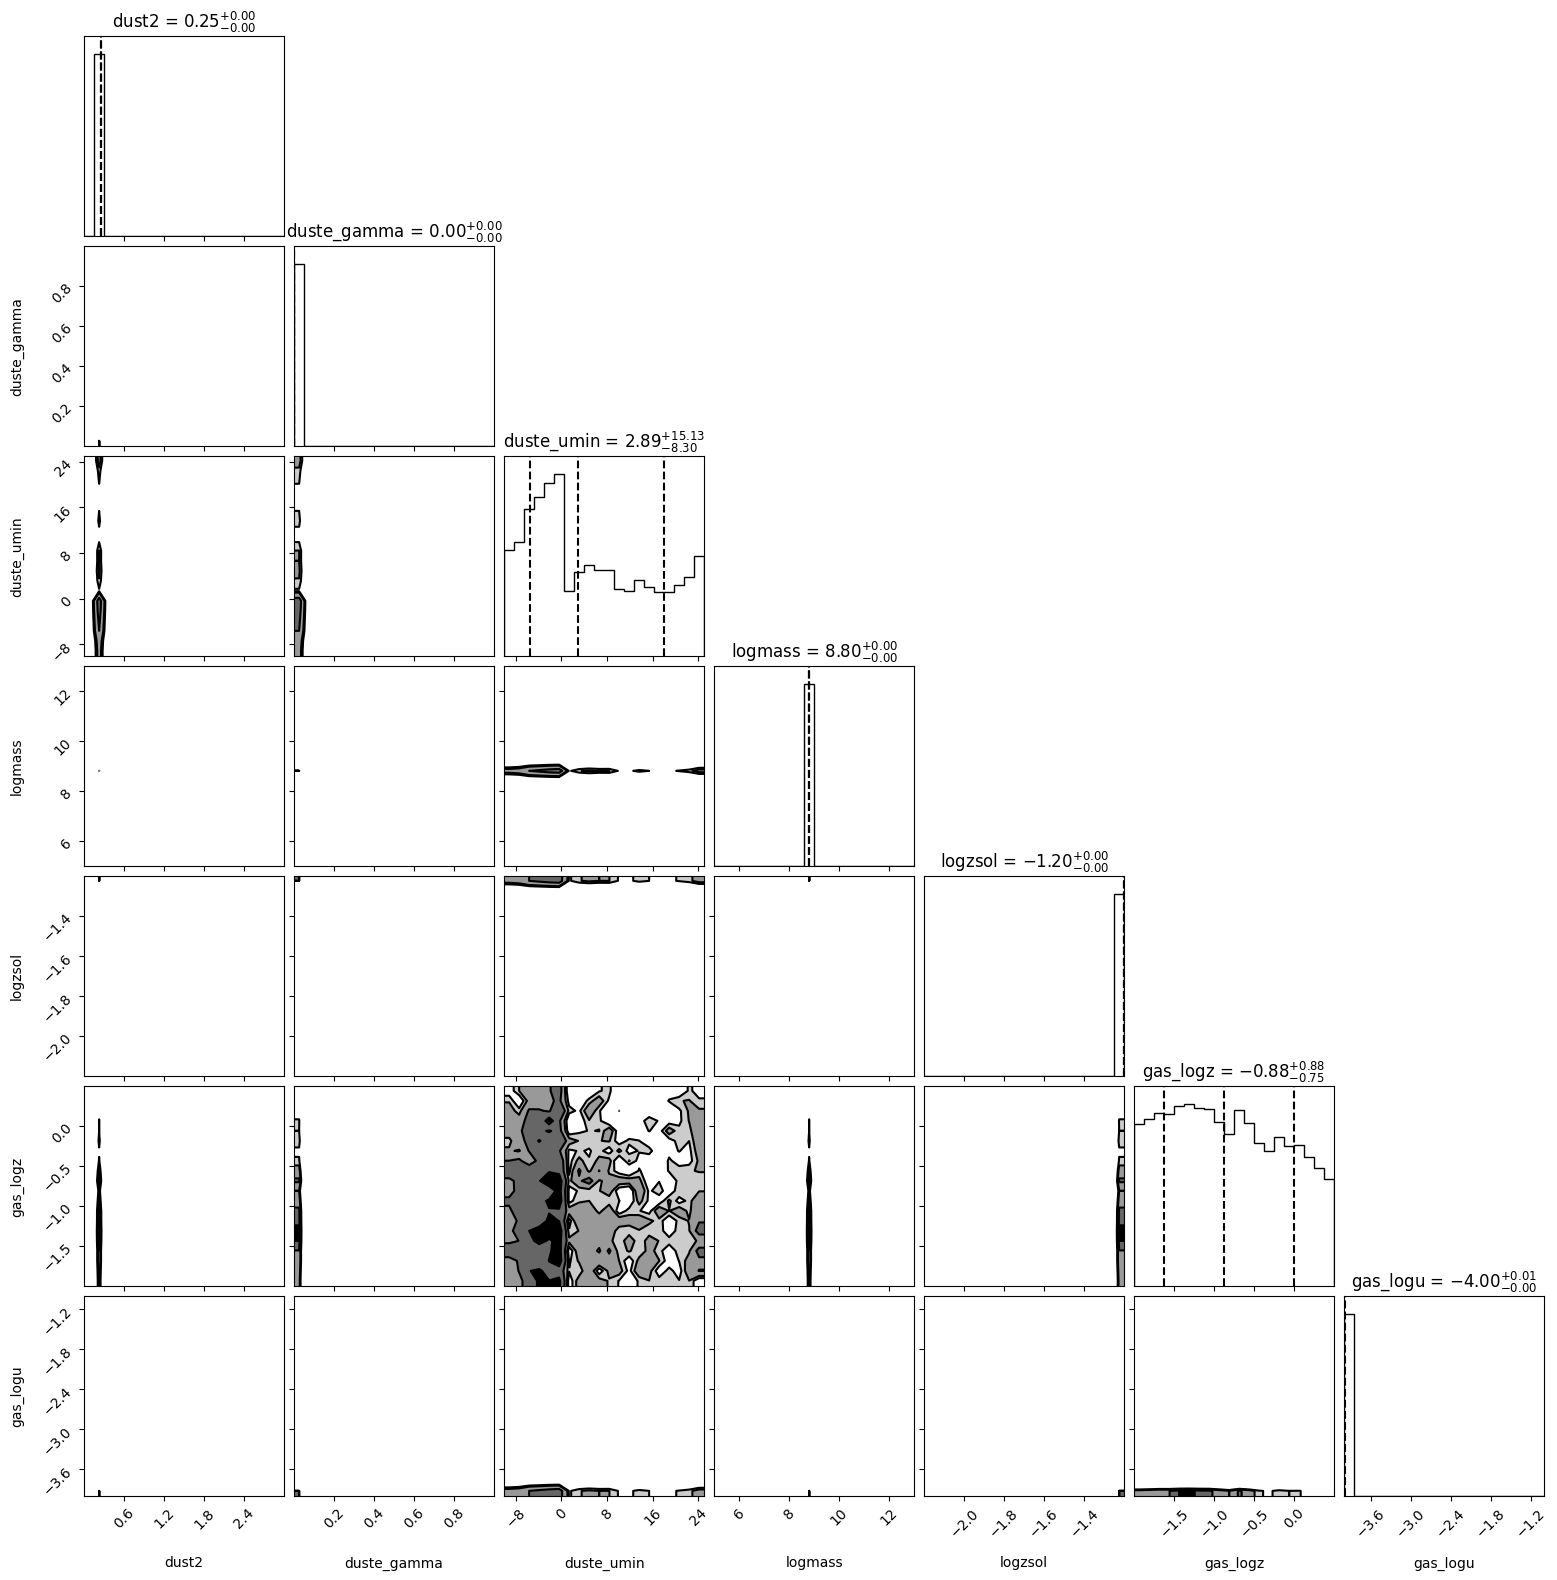

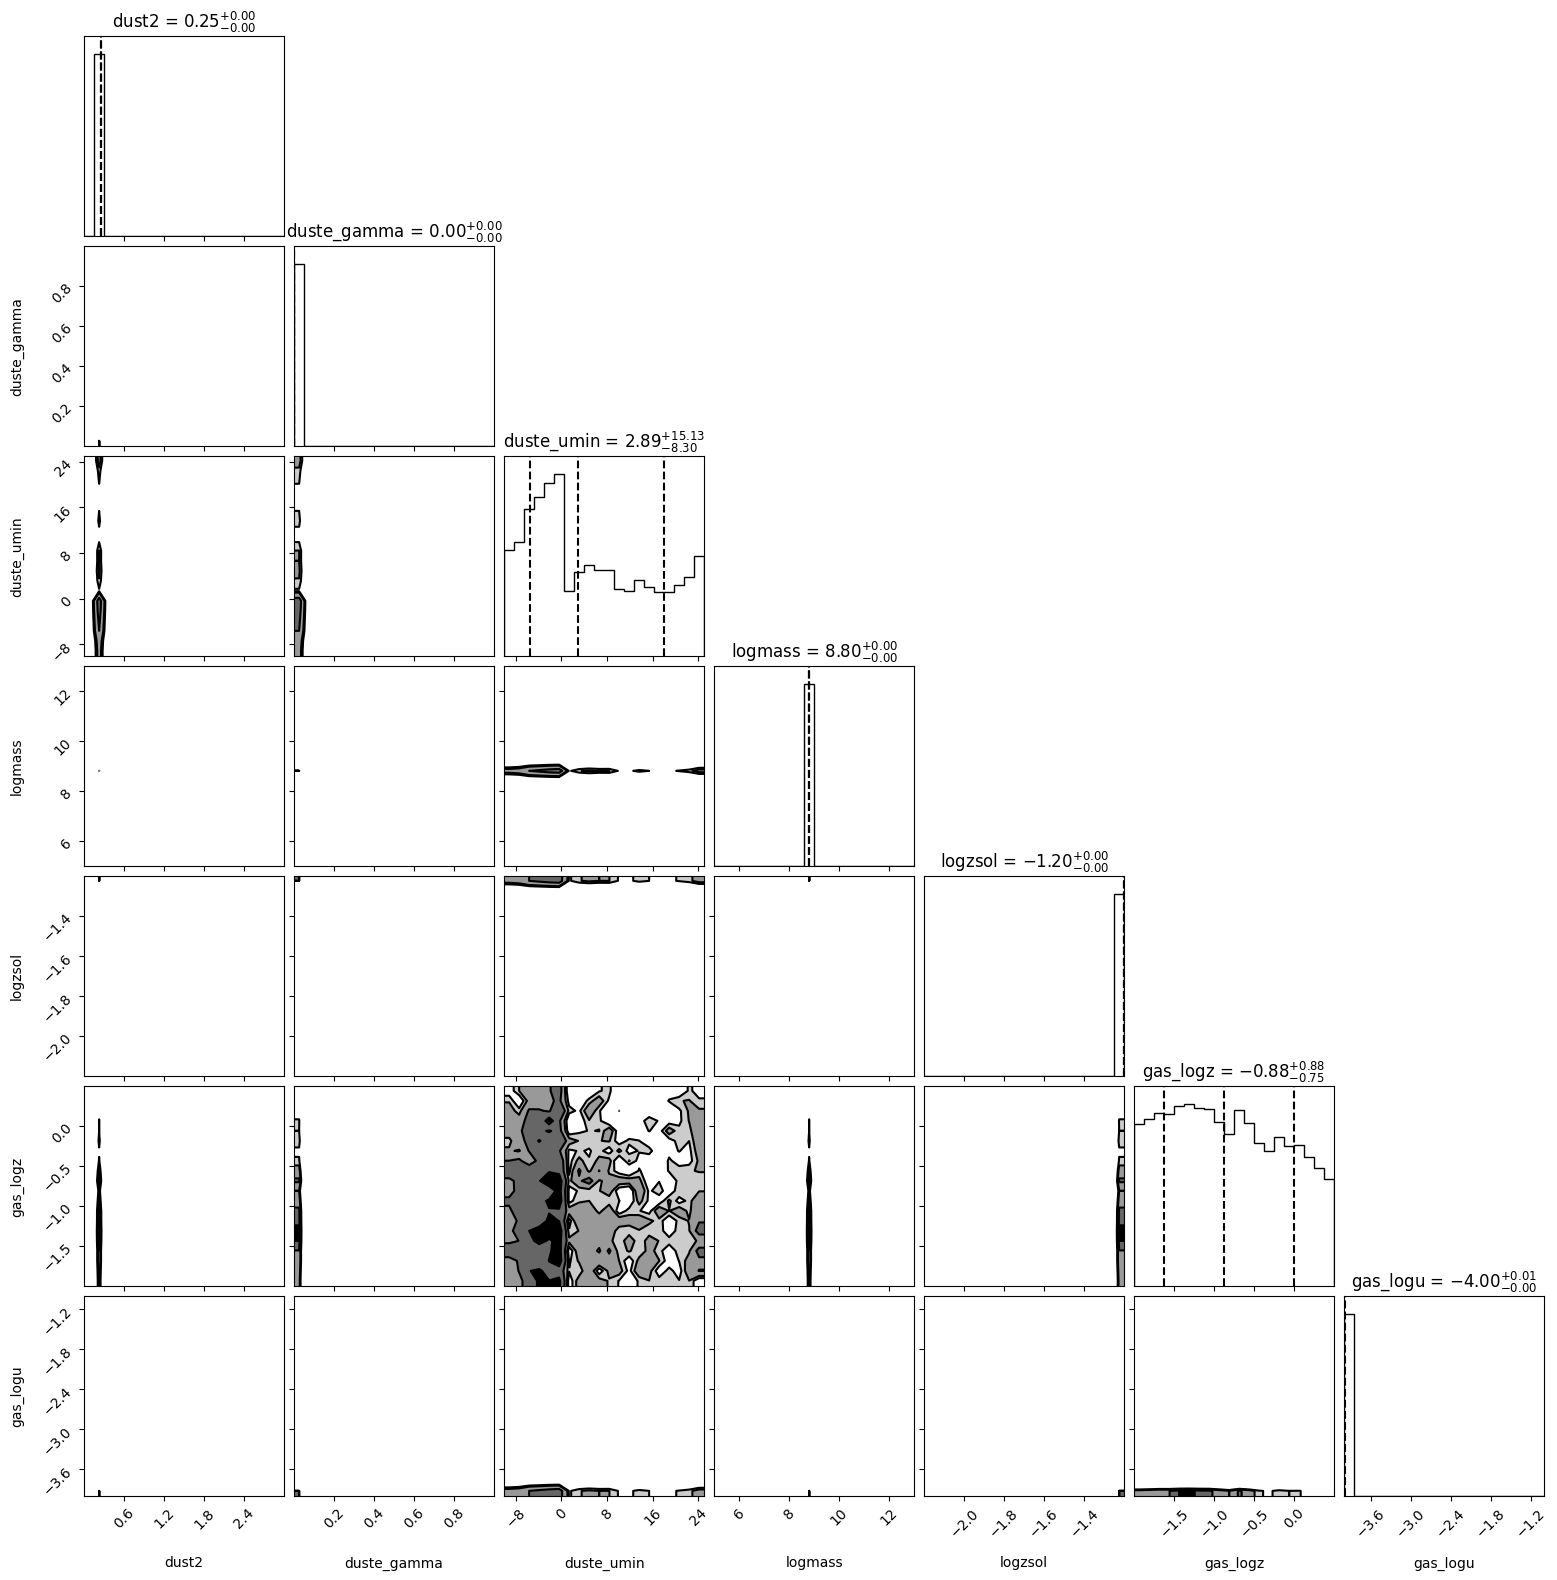

In [3]:
pread.subcorner(results, showpars=['dust2','duste_gamma','duste_umin','logmass','logzsol','gas_logz','gas_logu'])

In [4]:
from tqdm.auto import tqdm
seds_spec = []
seds_mag = []
surviving_mass_frac = []

weights = results.get('weights',None) #likelihood values
idx = np.argsort(weights)[-5000:] #select 5000 most likely
for i in tqdm(idx):
    thetas = results['chain'][i]
    spec, mags, mass_frac = model.predict(thetas,sps=sps,obs=observations_dict)
    seds_spec.append(spec)
    seds_mag.append(mags)
    surviving_mass_frac.append(mass_frac)

corrected_stellar_mass_posterior = 10**results['chain'][idx,model_params.index('logmass')] * np.array(surviving_mass_frac) 

/Users/thardy/Documents/durham/eelgs/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 5000/5000 [01:19<00:00, 63.10it/s]


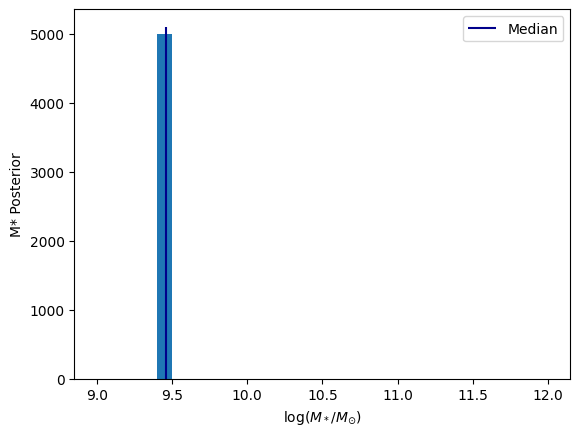

In [5]:
import matplotlib.pyplot as plt
n = plt.hist(np.log10(corrected_stellar_mass_posterior), range=(9, 12), bins=30)
plt.vlines(np.median(np.log10(corrected_stellar_mass_posterior)), ymin=0, ymax=np.max(n[0])+100, color='darkblue', label='Median')
plt.ylabel('M* Posterior')
plt.xlabel('$\log(M_* / M_{\odot})$')
plt.legend()

In [6]:
from prospect.models import transforms
def get_sfr(res, mod):
    agebins = mod.params['agebins']
    thetas = mod.theta_labels()                                                                                                                                           
    agebins_yrs = 10**agebins.T
    dt = agebins_yrs[1, :] - agebins_yrs[0, :]
    zfrac_idx = [i for i, s in enumerate(thetas) if 'z_fraction' in s]
    zfrac_chain = res['chain'][:,zfrac_idx[0]:zfrac_idx[-1]+1]
    
    total_mass_chain = res['chain'][:,thetas.index('logmass')]
    sfr_chain = []
    weights = results.get('weights',None) #likelihood values
    idx = np.argsort(weights)[-5000:]
    for i in idx:
        #this is the important part of this function -- it takes the proxy model parameters we sampled
        # and transforms them into the masses formed in each timebin
        # from there, we just divide these masses by the time in each bin to get the SFR in each bin
        masses_chain = transforms.zfrac_to_masses(10**total_mass_chain[i], zfrac_chain[i], agebins)
        sfr = masses_chain / dt                                                                                                                                  
        sfr_chain.append(sfr[0])                                                                                                                                                
    return sfr_chain

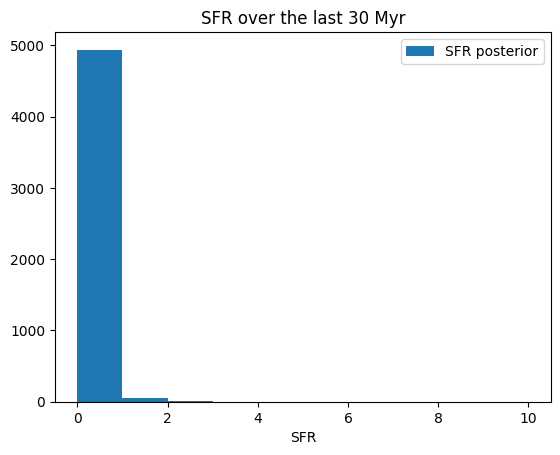

In [7]:
#now plot model SFR histogram
model_sfr = get_sfr(results, model)
n, _, _ = plt.hist(model_sfr, range=(0,10), label='SFR posterior')
plt.title('SFR over the last 30 Myr')
plt.xlabel('SFR')
plt.legend()

In [ ]:
data = {'log(M$_*$/M$_{\odot}$)\n': np.log10(corrected_stellar_mass_posterior),
       'log(Z$_*$/Z$_{\odot}$)\n': results['chain'][idx,model_params.index('logzsol')],
       'log(SFR)\n': np.log10(model_sfr),
       'A$_V$\n': results['chain'][idx,model_params.index('dust2')],
       'B$_V$\n': np.log10(results['chain'][idx,model_params.index('duste_gamma')]),
        'log$\;U_{\mathrm{gas}}$\n': results['chain'][idx,model_params.index('gas_logu')],
}
        
df = pd.DataFrame(data)

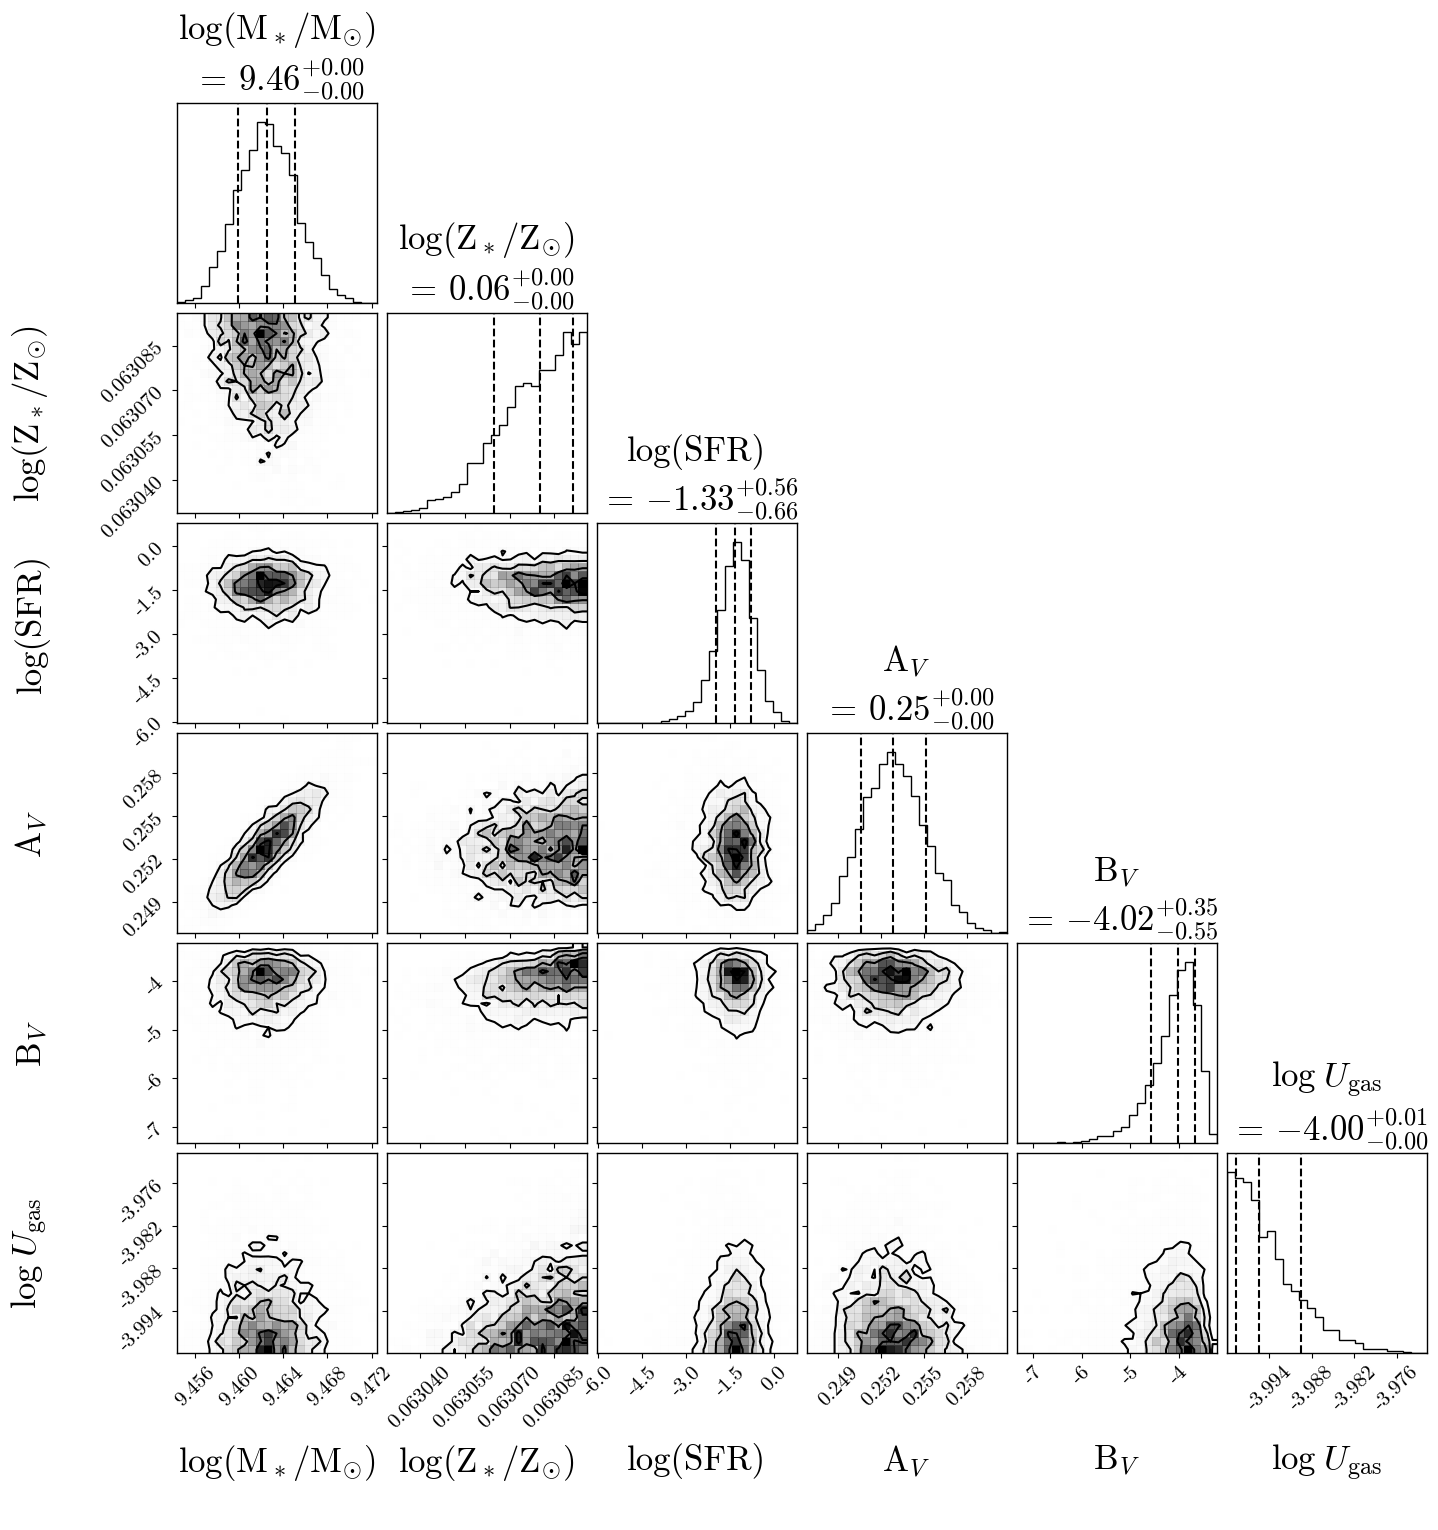

In [41]:
pf.housestyle_rcparams()
figure = corner.corner(df,labels=list(data.keys()),
                       quantiles=[0.16, 0.5, 0.84],
                       show_titles=True, title_kwargs={"fontsize": 25}, label_kwargs={'fontsize': 25}, labelpad=0.15,
                      bins=25,plot_datapoints=False)

Plot saved to sfh_plot.png


/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_53879/2647055866.py:46: RuntimeWarning: divide by zero encountered in log10
  ax.step(np.log10(plot_time), plot_sfr_50, where='pre', color='blue', lw=2, label='Median SFH')
/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_53879/2647055866.py:48: RuntimeWarning: divide by zero encountered in log10
  ax.fill_between(np.log10(plot_time), np.insert(sfr_16, 0, sfr_16[0]), np.insert(sfr_84, 0, sfr_84[0]),


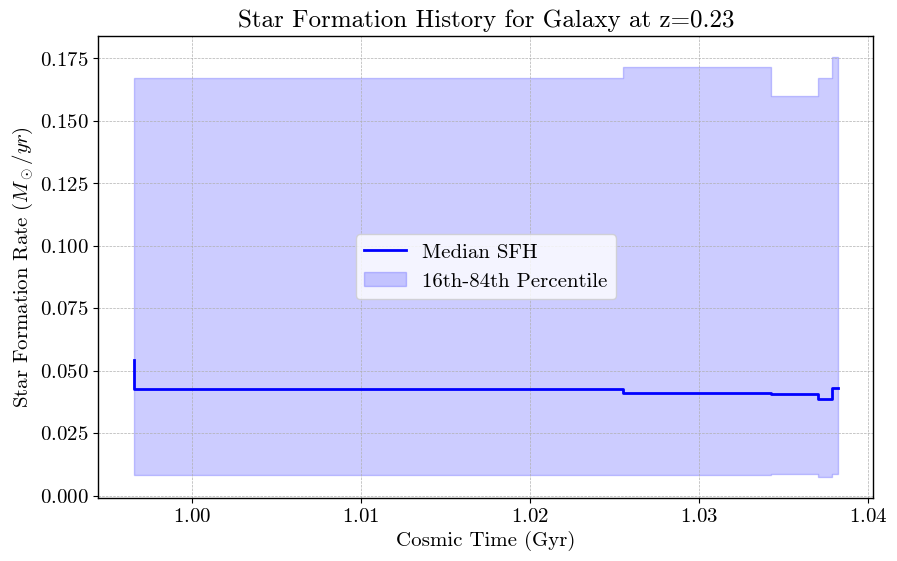

In [10]:
# theta_labels,agebins,zred = get_manual_model_params(17)

zred = ROW['z']
agebins = model.params['agebins'].T
theta_labels = results.get('theta_labels')

flatchain = results['chain']
if flatchain.size == 0:
    print(f"Error: The chain in the file is empty even when loaded with pread.")
# --- Get Model Info ---

# --- Process Posteriors ---
logmass_idx = theta_labels.index('logmass')
z_fraction_indices = [i for i, label in enumerate(theta_labels) if 'z_fraction' in label]

# --- Calculate SFR for each posterior sample ---
all_sfrs = []
for sample in flatchain:
    logmass_sample = sample[logmass_idx]
    z_fraction_sample = sample[z_fraction_indices]
    
    masses = zfrac_to_masses_log(logmass=logmass_sample, z_fraction=z_fraction_sample, agebins=agebins.T)
    bin_durations = 10**agebins[1] - 10**agebins[0]
    sfr = masses / bin_durations
    all_sfrs.append(sfr)

all_sfrs = np.array(all_sfrs)

# --- Convert to Cosmic Time ---
from astropy.cosmology import Planck18 as cosmo

lookback_time_bins = 10**agebins / 1e9
t_universe_at_z = cosmo.age(zred).value
cosmic_time_bins = t_universe_at_z - lookback_time_bins

# --- Calculate Percentiles ---
sfr_percentiles = np.percentile(all_sfrs, [16, 50, 84], axis=0)
sfr_16, sfr_50, sfr_84 = sfr_percentiles

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

plot_time = np.insert(cosmic_time_bins[1, :], 0, cosmic_time_bins[0, 0])
plot_sfr_50 = np.insert(sfr_50, 0, sfr_50[0])

ax.step(np.log10(plot_time), plot_sfr_50, where='pre', color='blue', lw=2, label='Median SFH')

ax.fill_between(np.log10(plot_time), np.insert(sfr_16, 0, sfr_16[0]), np.insert(sfr_84, 0, sfr_84[0]), 
                step='pre', color='blue', alpha=0.2, label='16th-84th Percentile')

ax.set_xlabel('Cosmic Time (Gyr)')
ax.set_ylabel(r'Star Formation Rate ($M_\odot / yr$)')
ax.set_title(f'Star Formation History for Galaxy at z={zred:.2f}')
# ax.set_xscale('log')
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)


# ax.set_xlim(0, t_universe_at_z)
# if np.any(sfr_16 > 0):
#     ax.set_ylim(bottom=np.min(sfr_16[sfr_16 > 0]) / 2, top=np.max(sfr_84) * 2)

# ax.set_ylim(0,4.9)

# ax.set_xticks([1,5,9,10])

plt.savefig('sfh_plot.png', dpi=300)
print("Plot saved to sfh_plot.png")


In [11]:
results

{'model_params': [{'name': 'logmass',
   'N': 1,
   'isfree': True,
   'init': 10.0,
   'units': 'Msun',
   'prior': b'\x80\x02cprospect.models.priors\nTopHat\nq\x00)\x81q\x01}q\x02(X\x05\x00\x00\x00aliasq\x03}q\x04(X\x04\x00\x00\x00miniq\x05h\x05X\x04\x00\x00\x00maxiq\x06h\x06uX\x06\x00\x00\x00paramsq\x07}q\x08(h\x05G@\x14\x00\x00\x00\x00\x00\x00h\x06G@*\x00\x00\x00\x00\x00\x00uX\x04\x00\x00\x00nameq\tX\x00\x00\x00\x00q\nub.'},
  {'name': 'z_fraction',
   'N': 5,
   'isfree': True,
   'init': array([0.83333333, 0.8       , 0.75      , 0.66666667, 0.5       ]),
   'units': '',
   'prior': b'\x80\x02cprospect.models.priors\nBeta\nq\x00)\x81q\x01}q\x02(X\x05\x00\x00\x00aliasq\x03}q\x04(X\x04\x00\x00\x00miniq\x05h\x05X\x04\x00\x00\x00maxiq\x06h\x06X\x05\x00\x00\x00alphaq\x07h\x07X\x04\x00\x00\x00betaq\x08h\x08uX\x06\x00\x00\x00paramsq\t}q\n(h\x05G\x00\x00\x00\x00\x00\x00\x00\x00h\x06G?\xf0\x00\x00\x00\x00\x00\x00h\x07cnumpy._core.multiarray\n_reconstruct\nq\x0bcnumpy\nndarray\nq\x0cK\x00\

In [12]:
chain = results.get('chain', None)
lnprobability = results.get('lnprobability', None)
flat_lnprobability = lnprobability.reshape(-1)
flat_chain = chain.reshape(-1, chain.shape[-1])
best_fit_index = np.argmax(flat_lnprobability)
bestfit_params = flat_chain[best_fit_index]

In [13]:
spec,phot,extras = model.predict(bestfit_params, sps=sps,obs=observations_dict)

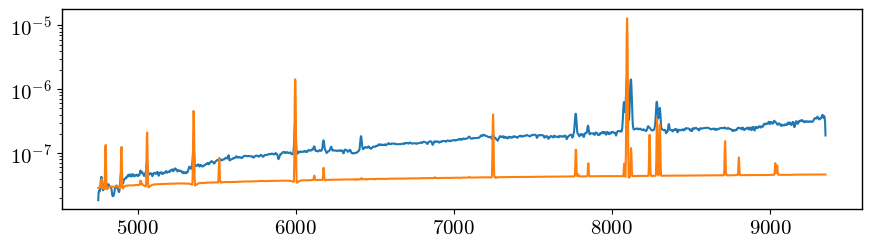

In [18]:
fig, ax = pf.create_plot([8,2])
ax.plot(observations_dict['wavelength'],observations_dict['spectrum'])
ax.plot(observations_dict['wavelength'],spec)

ax.set_yscale('log')

In [15]:
tab = Table(bestfit_params, names=theta_labels)
tab

logmass,z_fraction_1,z_fraction_2,z_fraction_3,z_fraction_4,z_fraction_5,dust2,logzsol,dust_index,dust1_fraction,duste_qpah,duste_gamma,duste_umin,gas_logz,gas_logu
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
8.8030596528882,0.992596997565714,0.8315883967292618,0.9823262518046493,0.8163634530631547,0.07610693401586573,0.25396668937529904,-1.200076522164356,-2.1890911347541038,1.9999485946803959,0.24902548158058369,9.426101704317747e-05,-3.3042315728653655,-0.5114389795231726,-3.9987177638333087


In [31]:
theta_labels

['logmass',
 'z_fraction_1',
 'z_fraction_2',
 'z_fraction_3',
 'z_fraction_4',
 'z_fraction_5',
 'dust2',
 'logzsol',
 'dust_index',
 'dust1_fraction',
 'duste_qpah',
 'duste_gamma',
 'duste_umin',
 'gas_logz',
 'gas_logu']

In [17]:
np.array([ 9.05965400e+00,  7.33257032e-01,  6.47968238e-01,  9.94875943e-01,
        9.50829573e-01,  9.06050945e-01,  4.28407559e-01, -1.20002023e+00,
       -2.19536299e+00,  1.19037737e-03,  3.43453268e-01,  8.38247924e-05,
        1.47367128e-01, -8.33800550e-01, -3.98061022e+00])

array([ 9.05965400e+00,  7.33257032e-01,  6.47968238e-01,  9.94875943e-01,
        9.50829573e-01,  9.06050945e-01,  4.28407559e-01, -1.20002023e+00,
       -2.19536299e+00,  1.19037737e-03,  3.43453268e-01,  8.38247924e-05,
        1.47367128e-01, -8.33800550e-01, -3.98061022e+00])